### 1. Define the Problem

ทำนายเวลา Qualifying ต่ำสุดจาก Q1/Q2/Q3 ด้วย **เวลา FP1–FP3 + ความยาวสนาม + จำนวนโค้ง** รวม 5 features หนึ่งแถวคือนักขับหนึ่งคนในหนึ่งรายการแข่ง ปี 2021–2023

### 2. Data Preparation

#### 2.1 ตั้งค่า library ปี และโฟลเดอร์
CSV อยู่ใน `data/final/raw` ส่วนข้อมูล clean และโมเดลแยกโฟลเดอร์ ใช้ `f1_cache` เดิมเพื่อลดการดาวน์โหลดซ้ำ

In [1]:
from pathlib import Path
import json
import hashlib
import time

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display

ROOT = Path.cwd().resolve()
if (ROOT / "f1_project").is_dir():
    ROOT = ROOT / "f1_project"

YEARS = [2021, 2022, 2023]
CACHE = ROOT / "f1_cache"
RAW = ROOT / "data/final/raw"
PROCESSED = ROOT / "data/final/processed"
MODELS = ROOT / "data/final/models"
CIRCUIT_FILE = ROOT / "data/final/reference/circuits.csv"

for folder in [CACHE, RAW, PROCESSED, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE))
print("FastF1:", fastf1.__version__)
print("ปี:", YEARS)
for folder in [CACHE, RAW, PROCESSED, MODELS]:
    print(folder)

FastF1: 3.8.3
ปี: [2021, 2022, 2023]
/workspace/f1_project/f1_cache
/workspace/f1_project/data/final/raw
/workspace/f1_project/data/final/processed
/workspace/f1_project/data/final/models


#### 2.2 อ่านรายการแข่งปี 2021–2023
ใช้ raw/events.csv ที่มากับ repo ก่อน ถ้าไม่มีจึงโหลดจาก FastF1 และบันทึก CSV
FastF1 ให้ชื่อรายการ ปีที่ขอโหลด และ RoundNumber; เราเพิ่ม Year และสร้าง event_id = ปี-เลขรอบ เช่น 2021-01 ไม่ใช่รหัสสนามจาก FastF1

In [2]:
if (RAW / "events.csv").exists():
    events = pd.read_csv(RAW / "events.csv")
    events = events.loc[events.Year.isin(YEARS)].copy()
    display(events[["event_id", "EventName", "EventFormat"]].head())
else:
    schedules = []
    for year in YEARS:
        schedule = fastf1.get_event_schedule(year, include_testing=False, backend="fastf1")
        if schedule.empty:
            raise ValueError(f"ไม่มีตารางปี {year}")
        table = pd.DataFrame(schedule).copy()
        table.insert(0, "Year", year)
        schedules.append(table)
        print(year, len(table), "รายการ")
    
    events = pd.concat(schedules, ignore_index=True)
    events["event_id"] = events.Year.astype(str) + "-" + events.RoundNumber.astype(int).astype(str).str.zfill(2)
    events.to_csv(RAW / "events.csv", index=False)
    display(events[["event_id", "EventName", "EventFormat"]].head())


,event_id,EventName,EventFormat
0,2021-01,Bahrain Grand Prix,conventional
1,2021-02,Emilia Romagna Grand Prix,conventional
2,2021-03,Portuguese Grand Prix,conventional
3,2021-04,Spanish Grand Prix,conventional
4,2021-05,Monaco Grand Prix,conventional


#### 2.3 เตรียมคำสั่งโหลดหนึ่งรายการ
โหลด Practice ทุก lap และผล Qualifying เก็บทุกคอลัมน์ที่ FastF1 ส่งมาโดยยังไม่ clean เวลา timedelta ยังเป็นข้อความใน CSV

เก็บเวลาเริ่ม/จบ session เพิ่ม เพื่อกัน Practice ที่เกิดหลัง Qualifying ออกจาก input ในขั้น 2.7
get_session(Year, RoundNumber, FP/Q) โหลดเฉพาะรายการที่กำลังวนอยู่ จึงใส่ event_id ของแถว events นั้นลงใน laps และ results ได้ตรง ๆ ไม่ได้เดารายการจากเวลารอบ; Session เป็นคอลัมน์ที่เราเพิ่มเองเช่นกัน

In [3]:
SESSION_NAMES = {"Practice 1": "FP1", "Practice 2": "FP2", "Practice 3": "FP3", "Qualifying": "Q"}

def utc_time(info, field):
    timestamp = pd.Timestamp(info[field])
    if pd.isna(timestamp):
        raise ValueError(f"ไม่มี {field} ของ session")
    if timestamp.tzinfo is None:
        timestamp = (timestamp - pd.Timedelta(info["GmtOffset"])).tz_localize("UTC")
    return timestamp.tz_convert("UTC").isoformat()

def load_event(event):
    practice, metadata, qualifying = [], [], None
    for slot in range(1, 6):
        name = SESSION_NAMES.get(event[f"Session{slot}"])
        if name is None:
            continue
        # FP3 Russia 2021 ถูกยกเลิกเพราะฝน: ไม่สร้าง lap ใน raw
        if (int(event.Year), int(event.RoundNumber), name) == (2021, 15, "FP3"):
            metadata.append({"event_id": event.event_id, "Session": name,
                             "start_utc": None, "end_utc": None,
                             "status": "cancelled", "reason": "Heavy rain",
                             "source_path": "https://www.fia.com/news/f1-norris-takes-first-f1-pole-position-russia-ahead-sainz-and-russell"})
            print("FP3 ยกเลิกเพราะฝน: เก็บเป็น missing ไม่มี lap ทดแทนใน raw")
            continue
        session = fastf1.get_session(int(event.Year), int(event.RoundNumber), name)
        session.load(laps=True, telemetry=False, weather=False, messages=True)
        info = session.session_info
        metadata.append({"event_id": event.event_id, "Session": name,
                         "start_utc": utc_time(info, "StartDate"),
                         "end_utc": utc_time(info, "EndDate"),
                         "source_path": session.api_path})
        if name == "Q":
            qualifying = pd.DataFrame(session.results).copy()
            if qualifying.empty:
                raise ValueError("ไม่มีผล Qualifying")
            qualifying.insert(0, "event_id", event.event_id)
        else:
            laps = pd.DataFrame(session.laps).copy()
            if laps.empty:
                raise ValueError(f"{name} ไม่มี lap ต้องตรวจว่า session ยกเลิกหรือโหลดไม่สำเร็จ")
            laps.insert(0, "Session", name)
            laps.insert(0, "event_id", event.event_id)
            practice.append(laps)
    if not practice or qualifying is None:
        raise ValueError("ไม่มี Practice หรือ Qualifying")
    return pd.concat(practice, ignore_index=True), qualifying, pd.DataFrame(metadata)

def csv_hashes(folder):
    return {path.name: hashlib.sha256(path.read_bytes()).hexdigest()
            for path in sorted(folder.glob("*.csv"))}

#### 2.4 โหลดทุกปี บันทึก raw แยกรายการใน `raw/events/`
โหลดตามลำดับและแสดงความคืบหน้า รายการที่บันทึกครบแล้วจะข้ามเมื่อรันซ้ำ ถ้ามีรายการโหลดไม่สำเร็จให้ส่งตาราง `failed` มาตรวจก่อน ไม่ถือว่าข้อมูลหายคือศูนย์

Raw คือข้อมูลก่อน cleaning ของเรา แต่ FastF1 มีการประมวลผลข้อมูลจากระบบจับเวลามาแล้ว

In [4]:
failed = []
for position, (_, event) in enumerate(events.iterrows(), start=1):
    folder = RAW / "events" / event.event_id
    folder.mkdir(parents=True, exist_ok=True)
    marker = folder / "complete.json"
    files = ["practice_laps.csv", "qualifying_results.csv", "sessions.csv"]
    if marker.exists() and all((folder / name).exists() for name in files):
        if json.loads(marker.read_text()) == csv_hashes(folder):
            print(f"[{position}/{len(events)}] {event.event_id} มี CSV ครบแล้ว")
            continue
    print(f"[{position}/{len(events)}] {event.event_id} {event.EventName}", flush=True)
    try:
        tables = load_event(event)
        for table, name in zip(tables, files):
            table.to_csv(folder / name, index=False)
        marker.write_text(json.dumps(csv_hashes(folder)), encoding="utf-8")
        print("บันทึกแล้ว:", len(tables[0]), "practice laps", flush=True)
    except Exception as error:
        failed.append({"event_id": event.event_id, "error": str(error)})
        print("ไม่สำเร็จ:", str(error), flush=True)
    time.sleep(1)

failed = pd.DataFrame(failed, columns=["event_id", "error"])
failed.to_csv(PROCESSED / "download_failures.csv", index=False)
display(failed)
print("รายการที่ต้องตรวจ:", len(failed))

[1/66] 2021-01 มี CSV ครบแล้ว
[2/66] 2021-02 มี CSV ครบแล้ว
[3/66] 2021-03 มี CSV ครบแล้ว
[4/66] 2021-04 มี CSV ครบแล้ว


[5/66] 2021-05 มี CSV ครบแล้ว
[6/66] 2021-06 มี CSV ครบแล้ว


[7/66] 2021-07 มี CSV ครบแล้ว
[8/66] 2021-08 มี CSV ครบแล้ว
[9/66] 2021-09 มี CSV ครบแล้ว


[10/66] 2021-10 มี CSV ครบแล้ว
[11/66] 2021-11 มี CSV ครบแล้ว
[12/66] 2021-12 มี CSV ครบแล้ว
[13/66] 2021-13 มี CSV ครบแล้ว


[14/66] 2021-14 มี CSV ครบแล้ว
[15/66] 2021-15 มี CSV ครบแล้ว
[16/66] 2021-16 มี CSV ครบแล้ว
[17/66] 2021-17 มี CSV ครบแล้ว


...

[58/66] 2023-14 มี CSV ครบแล้ว


[59/66] 2023-15 มี CSV ครบแล้ว
[60/66] 2023-16 มี CSV ครบแล้ว
[61/66] 2023-17 มี CSV ครบแล้ว
[62/66] 2023-18 มี CSV ครบแล้ว
[63/66] 2023-19 มี CSV ครบแล้ว


[64/66] 2023-20 มี CSV ครบแล้ว
[65/66] 2023-21 มี CSV ครบแล้ว
[66/66] 2023-22 มี CSV ครบแล้ว


,event_id,error


รายการที่ต้องตรวจ: 0


#### 2.5 รวมไฟล์เป็น `practice_laps.csv`, `qualifying_results.csv` และ `sessions.csv`
หยุดขั้นนี้ถ้ามีรายการโหลดไม่ครบ เลข `source_row` ที่จะเพิ่มตอน clean อ้างถึงแถวใน CSV รวม

In [5]:
assert failed.empty, "มีรายการโหลดไม่ครบ: ตรวจ download_failures.csv ก่อนรวมข้อมูล"

for name in ["practice_laps.csv", "qualifying_results.csv", "sessions.csv"]:
    if (RAW / name).exists():
        print(name, "ใช้ snapshot เดิม")
        continue
    parts = [pd.read_csv(RAW / "events" / event_id / name, low_memory=False)
             for event_id in events.event_id]
    combined = pd.concat(parts, ignore_index=True)
    combined.to_csv(RAW / name, index=False)
    print(name, len(combined), "แถว")

laps = pd.read_csv(RAW / "practice_laps.csv", low_memory=False)
results = pd.read_csv(RAW / "qualifying_results.csv", low_memory=False)
sessions = pd.read_csv(RAW / "sessions.csv")
raw_checksums = csv_hashes(RAW)
display(laps[["event_id", "Session", "Driver", "LapTime", "Compound", "TyreLife"]].head())

practice_laps.csv ใช้ snapshot เดิม
qualifying_results.csv ใช้ snapshot เดิม
sessions.csv ใช้ snapshot เดิม


,event_id,Session,Driver,LapTime,Compound,TyreLife
0,2021-01,FP1,RIC,NaN,HARD,1.0
1,2021-01,FP1,RIC,0 days 00:01:34.212000,HARD,2.0
2,2021-01,FP1,RIC,0 days 00:02:11.716000,HARD,3.0
3,2021-01,FP1,RIC,0 days 00:01:34.523000,HARD,4.0
4,2021-01,FP1,RIC,0 days 00:02:10.037000,HARD,5.0


#### 2.6 ตรวจ missing / duplicate และ clean lap
แปลงเวลาเป็นวินาที ตัดแถวซ้ำ ไม่มีเวลา/นักขับ เวลาไม่บวก ถูกลบเวลา ไม่แม่นยำ และแถวที่ FastF1 สร้าง เก็บเหตุผลแรกต่อแถวให้ยอดก่อน–หลังตรวจสอบได้ ยังไม่ตัดแถวที่ข้อมูลยางขาด

In [6]:
display(laps.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("แถวซ้ำ:", laps.duplicated().sum())

audit = laps.copy()
duplicates = audit.duplicated()
audit["source_row"] = np.arange(len(audit)) + 2
audit["LapTime"] = pd.to_timedelta(audit.LapTime, errors="coerce").dt.total_seconds()

def is_true(series):
    return series.astype("string").str.lower().isin(["true", "1"])

rules = {
    "duplicate": duplicates,
    "missing_time_or_driver": audit.LapTime.isna() | audit.Driver.isna(),
    "nonpositive_time": audit.LapTime.le(0),
    "deleted": is_true(audit.Deleted),
    "inaccurate": audit.IsAccurate.notna() & ~is_true(audit.IsAccurate),
    "generated": is_true(audit.FastF1Generated),
}
audit["reason"] = "kept"
remaining, cleaning_report = len(audit), []
for reason, mask in rules.items():
    audit[f"flag_{reason}"] = mask
    removed = audit.reason.eq("kept") & mask
    audit.loc[removed, "reason"] = reason
    count = int(removed.sum())
    cleaning_report.append({"rule": reason, "before": remaining, "removed": count, "after": remaining - count})
    remaining -= count

display(pd.DataFrame(cleaning_report))
assert remaining == audit.reason.eq("kept").sum()

,missing
LapStartDate,79661
Position,79661
DeletedReason,79052
PitInTime,65374
PitOutTime,65284
LapTime,14734
SpeedFL,14289
Sector1SessionTime,9543
Sector1Time,9476
Sector3SessionTime,2665


แถวซ้ำ: 0


,rule,before,removed,after
0,duplicate,79661,0,79661
1,missing_time_or_driver,79661,14734,64927
2,nonpositive_time,64927,0,64927
3,deleted,64927,609,64318
4,inaccurate,64318,13902,50416
5,generated,50416,0,50416


#### 2.7 ใช้เฉพาะ Practice ที่จบก่อน Qualifying
ใช้ metadata ของ session จริง ไม่เดาว่า FP2/FP3 ต้องอยู่ก่อน Q เสมอ แล้วบันทึก audit และข้อมูล clean แยกจาก raw

In [7]:
for column in ["start_utc", "end_utc"]:
    sessions[column] = pd.to_datetime(sessions[column], utc=True)
q_start = sessions.loc[sessions.Session.eq("Q")].set_index("event_id").start_utc
sessions["before_q"] = sessions.end_utc.lt(sessions.event_id.map(q_start))
audit = audit.merge(sessions[["event_id", "Session", "before_q"]],
                    on=["event_id", "Session"], how="left", validate="many_to_one")
audit["before_q"] = audit.before_q.eq(True)
after_q = audit.reason.eq("kept") & ~audit.before_q
audit.loc[after_q, "reason"] = "not_before_qualifying"
clean = audit.loc[audit.reason.eq("kept")].copy()

audit.to_csv(PROCESSED / "lap_audit.csv", index=False)
clean.to_csv(PROCESSED / "practice_clean.csv", index=False)
print("ตัดเพราะไม่ยืนยันว่าก่อน Q:", int(after_q.sum()))
print("เหลือ:", len(clean), "จาก", len(laps), "แถว")
display(audit.reason.value_counts().to_frame("rows"))

ตัดเพราะไม่ยืนยันว่าก่อน Q: 2662
เหลือ: 47754 จาก 79661 แถว


,rows
reason,
kept,47754
missing_time_or_driver,14734
inaccurate,13902
not_before_qualifying,2662
deleted,609


#### 2.8 ดึงรายละเอียดสนามและสร้าง features
ขั้นนี้สร้าง `circuits.csv` จากต้นฉบับ F1DB จริง ไม่ใช้รหัสที่เตรียมไว้ใน CSV เป็นหลักฐานในการจับคู่

##### 2.8.1 ดาวน์โหลดตารางรายการและไฟล์ race.yml จาก F1DB
ใช้ revision คงที่ (CC BY 4.0) เก็บไฟล์ต้นฉบับ, URL และ SHA256 ใน `reference/f1db/` หากมีต้นฉบับพร้อม checksum แล้วใช้ไฟล์นั้น ไม่โหลดซ้ำ ไม่ได้ใช้ FastF1 cache ในขั้นนี้

In [8]:
import requests
import yaml

F1DB_REV = "5487e45d4df4097080332f29a0513f275c1023cd"
SOURCE = CIRCUIT_FILE.parent / "f1db" / F1DB_REV
SOURCE.mkdir(parents=True, exist_ok=True)
manifest_file = SOURCE / "manifest.json"
manifest = json.loads(manifest_file.read_text()) if manifest_file.exists() else {}

def fetch_source(relative_path, url):
    path = SOURCE / relative_path
    if path.exists():
        saved = manifest.get(relative_path, {})
        assert saved.get("url") == url, f"ไม่มีหลักฐาน URL: {path}"
        assert saved.get("sha256") == hashlib.sha256(path.read_bytes()).hexdigest(), f"ต้นทางเปลี่ยน: {path}"
    else:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(response.content)
        manifest[relative_path] = {"url": url, "sha256": hashlib.sha256(response.content).hexdigest()}
        manifest_file.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    return path

source_rows = []
for year in YEARS:
    index_url = f"https://api.github.com/repos/f1db/f1db/contents/src/data/seasons/{year}/races?ref={F1DB_REV}"
    index = fetch_source(f"{year}/index.json", index_url)
    directories = [item["name"] for item in json.loads(index.read_text()) if item["type"] == "dir"]
    for directory in sorted(directories):
        url = f"https://raw.githubusercontent.com/f1db/f1db/{F1DB_REV}/src/data/seasons/{year}/races/{directory}/race.yml"
        relative_path = f"{year}/{directory}/race.yml"
        path = fetch_source(relative_path, url)
        race = yaml.safe_load(path.read_text())
        grand_prix_path = f"grands-prix/{race['grandPrixId']}.yml"
        grand_prix_url = f"https://raw.githubusercontent.com/f1db/f1db/{F1DB_REV}/src/data/grands-prix/{race['grandPrixId']}.yml"
        grand_prix_file = fetch_source(grand_prix_path, grand_prix_url)
        grand_prix = yaml.safe_load(grand_prix_file.read_text())
        assert grand_prix["id"] == race["grandPrixId"], "รหัส Grand Prix ในต้นฉบับไม่ตรง"
        source_rows.append({
            "Year": year, "f1db_round": race["round"], "f1db_date": str(race["date"]),
            "f1db_name": race["officialName"], "grand_prix_id": race["grandPrixId"],
            "grand_prix_name": grand_prix["fullName"], "grand_prix_source_url": grand_prix_url,
            "grand_prix_source_file": grand_prix_path,
            "grand_prix_source_sha256": hashlib.sha256(grand_prix_file.read_bytes()).hexdigest(),
            "circuit_id": race["circuitId"], "layout_id": race["circuitLayoutId"],
            "circuit_length_km": race["courseLength"], "corner_count": race["turns"],
            "source_url": url, "source_file": relative_path,
            "source_sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        })
    print(year, len(directories), "รายการจาก F1DB")

f1db = pd.DataFrame(source_rows)
print("ต้นฉบับที่ยังไม่จับคู่:", SOURCE.resolve())
display(f1db[["Year", "f1db_round", "f1db_date", "f1db_name", "circuit_id"]].head())
print((SOURCE / f1db.iloc[0].source_file).read_text())


2021 22 รายการจาก F1DB


2022 22 รายการจาก F1DB


2023 22 รายการจาก F1DB
ต้นฉบับที่ยังไม่จับคู่: /workspace/f1_project/data/final/reference/f1db/5487e45d4df4097080332f29a0513f275c1023cd


,Year,f1db_round,f1db_date,f1db_name,circuit_id
0,2021,1,2021-03-28,Formula 1 Gulf Air Bahrain Grand Prix 2021,bahrain
1,2021,2,2021-04-18,Formula 1 Pirelli Gran Premio del Made in Ital...,imola
2,2021,3,2021-05-02,Formula 1 Heineken Grande Prémio de Portugal 2021,portimao
3,2021,4,2021-05-09,Formula 1 Aramco Gran Premio de España 2021,catalunya
4,2021,5,2021-05-23,Formula 1 Grand Prix de Monaco 2021,monaco


id: 1036
round: 1
date: 2021-03-28
grandPrixId: bahrain
officialName: Formula 1 Gulf Air Bahrain Grand Prix 2021
qualifyingFormat: KNOCKOUT
circuitId: bahrain
circuitLayoutId: bahrain-1
circuitType: RACE
direction: CLOCKWISE
courseLength: 5.412
turns: 15
laps: 56
distance: 302.826
scheduledLaps: 57
scheduledDistance: 308.238



##### 2.8.2 จับคู่รายการแข่งและแสดงหลักฐานทั้งสองฝั่ง
ดึงชื่อ Grand Prix จากไฟล์ grands-prix ของ F1DB ตาม grandPrixId ใน race.yml แล้วจับคู่กับ EventName ของ FastF1 ด้วยปี + ชื่อที่ normalize ตรวจวันแข่งท้องถิ่นหรือ UTC เพิ่ม ไม่ใช้เลข round ข้ามแหล่ง และไม่กำหนดว่า event_id ใดต้องเป็นสนามใดเอง
ชื่อทางการที่มีผู้สนับสนุนอาจต่างกัน จึงใช้ชื่อ Grand Prix ก่อน ถ้าจับคู่ไม่ได้จึงใช้ชื่อทางการที่ตรงกันทั้งชื่อ + ปี (เช่น Mexico City / Mexican) ทุกคู่ยังต้องผ่านการตรวจวันที่ ไม่ใช้ fuzzy match
Las Vegas 2023 ตรวจด้วยวัน Race UTC ส่วน Turkey 2021 ระบุข้อยกเว้นวันที่ต้นทางในโค้ด โดยชื่อ Grand Prix ยังต้องตรง ถ้าพบรายการอื่นไม่ตรงหรือมีคู่ซ้ำให้หยุด

In [9]:
def name_key(values):
    return values.str.lower().str.replace(r"[^a-z0-9]", "", regex=True)

def match_circuits(events, f1db):
    left = events[["event_id", "Year", "EventName", "OfficialEventName", "EventDate"]].copy()
    left["fastf1_date"] = pd.to_datetime(left.EventDate).dt.strftime("%Y-%m-%d")
    left["race_utc_date"] = None
    for slot in range(1, 6):
        is_race = events[f"Session{slot}"].eq("Race")
        dates = pd.to_datetime(events[f"Session{slot}DateUtc"], utc=True).dt.strftime("%Y-%m-%d")
        left.loc[is_race, "race_utc_date"] = dates.loc[is_race]
    left["name_key"] = name_key(left.EventName)
    right = f1db.copy()
    right["name_key"] = name_key(right.grand_prix_name)
    assert left.event_id.is_unique, "FastF1 event_id ซ้ำ"
    assert not left.duplicated(["Year", "name_key"]).any(), "ชื่อรายการ FastF1 ไม่เป็นคู่ที่ชัดเจน"
    assert not right.duplicated(["Year", "name_key"]).any(), "ชื่อรายการ F1DB ไม่เป็นคู่ที่ชัดเจน"

    # จับคู่ด้วยปี + ชื่อ Grand Prix จากต้นฉบับ แล้วตรวจวันที่อีกชั้น ไม่เดาชื่อผู้สนับสนุน
    pairs = left.merge(right, on=["Year", "name_key"], how="left", validate="one_to_one", indicator=True)
    pairs["name_match"] = "Grand Prix name"
    # Mexico City Grand Prix / Mexican Grand Prix ชื่อต่างกัน แต่ชื่อทางการตรงกัน
    missing = left.event_id.isin(pairs.loc[pairs._merge.ne("both"), "event_id"])
    if missing.any():
        fallback_left = left.loc[missing].copy()
        fallback_left["name_key"] = name_key(fallback_left.OfficialEventName)
        fallback_right = right.copy()
        fallback_right["name_key"] = name_key(fallback_right.f1db_name)
        assert not fallback_right.duplicated(["Year", "name_key"]).any(), "ชื่อทางการ F1DB ซ้ำ"
        fallback = fallback_left.merge(fallback_right, on=["Year", "name_key"], how="left",
                                       validate="one_to_one", indicator=True)
        fallback["name_match"] = "official name"
        pairs = pd.concat([pairs.loc[pairs._merge.eq("both")], fallback], ignore_index=True)
    pairs = pairs.sort_values("event_id").reset_index(drop=True)
    unmatched = pairs.loc[pairs._merge.ne("both"), ["event_id", "EventName", "OfficialEventName"]]
    assert unmatched.empty, f"จับคู่ไม่ได้ ห้ามเดาสนาม:\\n{unmatched.to_string(index=False)}"
    local_match = pairs.fastf1_date.eq(pairs.f1db_date)
    utc_match = pairs.race_utc_date.eq(pairs.f1db_date)
    pairs["match_method"] = np.select([local_match, utc_match], [pairs.name_match + " + local_date", pairs.name_match + " + UTC_date"],
                                      default=pairs.name_match + "; source date mismatch")

    # F1DB revision นี้ลงวัน Turkey 2021 เป็น 3 ต.ค.; FastF1 ลง 10 ต.ค.
    # อนุญาตเฉพาะกรณีนี้โดยชื่อ Grand Prix ต้องตรงกัน ห้ามใช้เลข round หรือ event_id เดาว่าเป็นสนามอะไร
    known_date_mismatch = (pairs.Year.eq(2021) & pairs.grand_prix_id.eq("turkey")
                          & pairs.fastf1_date.eq("2021-10-10") & pairs.f1db_date.eq("2021-10-03"))
    unexpected = pairs.loc[~(local_match | utc_match | known_date_mismatch)]
    assert unexpected.empty, f"วันที่ไม่ตรง ต้องตรวจแหล่งข้อมูลก่อน:\\n{unexpected.to_string(index=False)}"
    assert pairs[["circuit_id", "layout_id", "source_url"]].notna().all().all(), "รายละเอียดสนามขาด"
    for column in ["circuit_length_km", "corner_count"]:
        values = pd.to_numeric(pairs[column], errors="coerce")
        assert (np.isfinite(values) & values.gt(0)).all(), f"{column} ไม่ถูกต้อง"
    assert pairs.corner_count.mod(1).eq(0).all(), "จำนวนโค้งต้องเป็นจำนวนเต็ม"
    pairs["corner_count"] = pairs.corner_count.astype(int)
    pairs["f1db_round"] = pairs.f1db_round.astype(int)
    return pairs.drop(columns=["_merge", "name_key"])

circuit_matches = match_circuits(events, f1db)
with pd.option_context("display.max_rows", None):
    display(circuit_matches[["event_id", "EventName", "grand_prix_name", "fastf1_date", "race_utc_date", "f1db_date", "circuit_id", "match_method"]])
print("กรณีที่ต้องอ่านหลักฐานเพิ่ม:")
display(circuit_matches.loc[circuit_matches.match_method.ne("Grand Prix name + local_date"),
                           ["event_id", "OfficialEventName", "f1db_name", "fastf1_date", "race_utc_date", "f1db_date", "match_method", "source_url"]])


,event_id,EventName,grand_prix_name,fastf1_date,race_utc_date,f1db_date,circuit_id,match_method
0,2021-01,Bahrain Grand Prix,Bahrain Grand Prix,2021-03-28,2021-03-28,2021-03-28,bahrain,Grand Prix name + local_date
1,2021-02,Emilia Romagna Grand Prix,Emilia Romagna Grand Prix,2021-04-18,2021-04-18,2021-04-18,imola,Grand Prix name + local_date
2,2021-03,Portuguese Grand Prix,Portuguese Grand Prix,2021-05-02,2021-05-02,2021-05-02,portimao,Grand Prix name + local_date
3,2021-04,Spanish Grand Prix,Spanish Grand Prix,2021-05-09,2021-05-09,2021-05-09,catalunya,Grand Prix name + local_date
4,2021-05,Monaco Grand Prix,Monaco Grand Prix,2021-05-23,2021-05-23,2021-05-23,monaco,Grand Prix name + local_date
5,2021-06,Azerbaijan Grand Prix,Azerbaijan Grand Prix,2021-06-06,2021-06-06,2021-06-06,baku,Grand Prix name + local_date
6,2021-07,French Grand Prix,French Grand Prix,2021-06-20,2021-06-20,2021-06-20,paul-ricard,Grand Prix name + local_date
7,2021-08,Styrian Grand Prix,Styrian Grand Prix,2021-06-27,2021-06-27,2021-06-27,spielberg,Grand Prix name + local_date
8,2021-09,Austrian Grand Prix,Austrian Grand Prix,2021-07-04,2021-07-04,2021-07-04,spielberg,Grand Prix name + local_date
9,2021-10,British Grand Prix,British Grand Prix,2021-07-18,2021-07-18,2021-07-18,silverstone,Grand Prix name + local_date


กรณีที่ต้องอ่านหลักฐานเพิ่ม:


,event_id,OfficialEventName,f1db_name,fastf1_date,race_utc_date,f1db_date,match_method,source_url
15,2021-16,FORMULA 1 ROLEX TURKISH GRAND PRIX 2021,Formula 1 Rolex Turkish Grand Prix 2021,2021-10-10,2021-10-10,2021-10-03,Grand Prix name; source date mismatch,https://raw.githubusercontent.com/f1db/f1db/54...
17,2021-18,FORMULA 1 GRAN PREMIO DE LA CIUDAD DE MÉXICO 2021,Formula 1 Gran Premio de la Ciudad de México 2021,2021-11-07,2021-11-07,2021-11-07,official name + local_date,https://raw.githubusercontent.com/f1db/f1db/54...
41,2022-20,FORMULA 1 HEINEKEN GRAN PREMIO DE LA CIUDAD DE...,Formula 1 Heineken Gran Premio de la Ciudad de...,2022-10-30,2022-10-30,2022-10-30,official name + local_date,https://raw.githubusercontent.com/f1db/f1db/54...
62,2023-19,FORMULA 1 GRAN PREMIO DE LA CIUDAD DE MÉXICO 2023,Formula 1 Gran Premio de la Ciudad de México 2023,2023-10-29,2023-10-29,2023-10-29,official name + local_date,https://raw.githubusercontent.com/f1db/f1db/54...
64,2023-21,FORMULA 1 HEINEKEN SILVER LAS VEGAS GRAND PRIX...,Formula 1 Heineken Silver Las Vegas Grand Prix...,2023-11-18,2023-11-19,2023-11-19,Grand Prix name + UTC_date,https://raw.githubusercontent.com/f1db/f1db/54...


##### 2.8.3 บันทึกผลจับคู่และอ่าน CSV กลับ
`circuit_matches.csv` เก็บชื่อ/วันที่ทั้งสองแหล่ง วิธีจับคู่ URL และ checksum ต้นฉบับ ส่วน `circuits.csv` เลือกเฉพาะรายละเอียดสนามที่ต้องใช้ จึงตรวจย้อนกลับได้ว่า event_id มาจากแถว FastF1 ใด

In [10]:
circuit_matches.to_csv(CIRCUIT_FILE.parent / "circuit_matches.csv", index=False)
columns = ["event_id", "circuit_id", "layout_id", "circuit_length_km", "corner_count", "source_url"]
circuits = circuit_matches[columns].sort_values("event_id").reset_index(drop=True)
csv_bytes = circuits.to_csv(index=False, float_format="%.3f").encode("utf-8")
if CIRCUIT_FILE.exists() and CIRCUIT_FILE.read_bytes() == csv_bytes:
    print("สร้างจากต้นฉบับแล้วได้ circuits.csv ตรงกับเดิมทุก byte")
else:
    CIRCUIT_FILE.write_bytes(csv_bytes)
    print("บันทึก circuits.csv จากผลจับคู่ใหม่: ต้องรันข้อ 3–5 ก่อนเปิดเว็บ")
saved_circuits = pd.read_csv(CIRCUIT_FILE)
pd.testing.assert_frame_equal(saved_circuits, circuits, check_dtype=False)
assert set(saved_circuits.event_id) == set(events.event_id), "ต้องมีสนามหนึ่งแถวต่อรายการครบทุก event"
print(CIRCUIT_FILE.resolve())
print("หลักฐาน:", (CIRCUIT_FILE.parent / "circuit_matches.csv").resolve())
display(saved_circuits.head())


สร้างจากต้นฉบับแล้วได้ circuits.csv ตรงกับเดิมทุก byte
/workspace/f1_project/data/final/reference/circuits.csv
หลักฐาน: /workspace/f1_project/data/final/reference/circuit_matches.csv


,event_id,circuit_id,layout_id,circuit_length_km,corner_count,source_url
0,2021-01,bahrain,bahrain-1,5.412,15,https://raw.githubusercontent.com/f1db/f1db/54...
1,2021-02,imola,imola-3,4.909,19,https://raw.githubusercontent.com/f1db/f1db/54...
2,2021-03,portimao,portimao-1,4.653,15,https://raw.githubusercontent.com/f1db/f1db/54...
3,2021-04,catalunya,catalunya-5,4.675,16,https://raw.githubusercontent.com/f1db/f1db/54...
4,2021-05,monaco,monaco-6,3.337,19,https://raw.githubusercontent.com/f1db/f1db/54...


##### 2.8.4 เลือก lap ซ้อมเร็วที่สุด แล้วเชื่อมรายละเอียดสนาม
เลือกเวลา FP ราย event_id + Driver แล้วเชื่อมกับ circuits.csv ที่สร้างใน 2.8.1–2.8.3 ใช้เฉพาะความยาว (km) และจำนวนโค้งเป็น features ไม่ใช้รหัสสนามเป็น input

In [11]:
PRACTICES = ["FP1", "FP2", "FP3"]
TIMES = [f"{s}_Time" for s in PRACTICES]
CIRCUIT_FEATURES = ["circuit_length_km", "corner_count"]
FEATURES = TIMES + CIRCUIT_FEATURES

best = clean.sort_values(["LapTime", "source_row"], kind="stable").drop_duplicates(
    ["event_id", "Driver", "Session"]
)
display(best[["source_row", "event_id", "Driver", "Session", "LapTime"]].head())

target = results.rename(columns={"Abbreviation": "Driver"}).copy()
print("ผล Qualifying ซ้ำ:", target.duplicated(["event_id", "Driver"]).sum())
target = target.drop_duplicates(["event_id", "Driver"])
for column in ["Q1", "Q2", "Q3"]:
    seconds = pd.to_timedelta(target[column], errors="coerce").dt.total_seconds()
    target[column] = seconds.where(seconds.gt(0))
target["QualiTime"] = target[["Q1", "Q2", "Q3"]].min(axis=1)
features = target[["event_id", "Driver", "QualiTime"]].merge(
    events[["event_id", "Year", "EventName"]], on="event_id", validate="many_to_one"
)

for session_name in PRACTICES:
    columns = {"LapTime": "Time", "source_row": "source_row"}
    selected = best.loc[best.Session.eq(session_name), ["event_id", "Driver", *columns]]
    selected = selected.rename(columns={c: f"{session_name}_{suffix}" for c, suffix in columns.items()})
    features = features.merge(selected, on=["event_id", "Driver"], how="left", validate="one_to_one")

circuits = pd.read_csv(CIRCUIT_FILE)
assert circuits.event_id.is_unique, "ข้อมูลสนามซ้ำ"
assert set(events.event_id) <= set(circuits.event_id), "ข้อมูลสนามไม่ครบ"
features = features.merge(circuits, on="event_id", how="left", validate="many_to_one")
assert features[CIRCUIT_FEATURES].notna().all().all(), "ห้ามเดาข้อมูลสนามที่ขาด"
assert features.circuit_length_km.gt(0).all() and features.corner_count.gt(0).all()
display(circuits[["event_id", "layout_id", *CIRCUIT_FEATURES, "source_url"]].head())
features.to_csv(PROCESSED / "features_before_fill.csv", index=False)
display(features[["event_id", "Driver", *FEATURES, "QualiTime"]].head())

,source_row,event_id,Driver,Session,LapTime
11059,11061,2021-08,HAM,FP3,64.369
12318,12320,2021-09,HAM,FP2,64.523
11043,11045,2021-08,VER,FP3,64.573
12828,12830,2021-09,VER,FP3,64.591
12455,12457,2021-09,BOT,FP2,64.712


ผล Qualifying ซ้ำ: 0


,event_id,layout_id,circuit_length_km,corner_count,source_url
0,2021-01,bahrain-1,5.412,15,https://raw.githubusercontent.com/f1db/f1db/54...
1,2021-02,imola-3,4.909,19,https://raw.githubusercontent.com/f1db/f1db/54...
2,2021-03,portimao-1,4.653,15,https://raw.githubusercontent.com/f1db/f1db/54...
3,2021-04,catalunya-5,4.675,16,https://raw.githubusercontent.com/f1db/f1db/54...
4,2021-05,monaco-6,3.337,19,https://raw.githubusercontent.com/f1db/f1db/54...


,event_id,Driver,FP1_Time,FP2_Time,FP3_Time,circuit_length_km,corner_count,QualiTime
0,2021-01,VER,91.394,90.847,90.577,5.412,15,88.997
1,2021-01,HAM,91.921,91.082,91.316,5.412,15,89.385
2,2021-01,BOT,91.692,91.218,91.855,5.412,15,89.586
3,2021-01,LEC,91.993,91.612,92.482,5.412,15,89.678
4,2021-01,GAS,92.195,91.483,91.583,5.412,15,89.809


#### 2.9 เติมเวลาซ้อมที่ขาด
ไม่มี target ไม่นำไปฝึก; ไม่มี Practice เลยไม่ทำนาย ถ้าขาดบาง FP ใช้เวลา FP ที่เร็วที่สุดในแถวนั้น พร้อมบอกว่าเติมจาก FP ใด รายละเอียดสนามต้องครบ ไม่เติมด้วย median

In [12]:
print("ไม่มี target:", features.QualiTime.isna().sum())
print("ไม่มี Practice เลย:", features[TIMES].isna().all(axis=1).sum())
dataset = features.loc[features.QualiTime.notna() & features[TIMES].notna().any(axis=1)].copy()

def fill_sessions(frame):
    filled = frame.copy()
    filled[TIMES] = filled[TIMES].apply(pd.to_numeric, errors="raise")
    invalid = filled[TIMES].notna() & (~np.isfinite(filled[TIMES]) | filled[TIMES].le(0))
    if invalid.any().any():
        raise ValueError("เวลาซ้อมต้องเป็นตัวเลขบวก")
    if filled[TIMES].isna().all(axis=1).any():
        raise ValueError("ต้องมี Practice อย่างน้อยหนึ่ง session")
    fastest = filled[TIMES].idxmin(axis=1).str.replace("_Time", "", regex=False)
    best_time = filled[TIMES].min(axis=1)
    for session_name in PRACTICES:
        missing = filled[f"{session_name}_Time"].isna()
        filled[f"{session_name}_filled_from"] = session_name
        filled.loc[missing, f"{session_name}_Time"] = best_time[missing]
        filled.loc[missing, f"{session_name}_filled_from"] = fastest[missing]
    return filled

dataset = fill_sessions(dataset)
dataset.to_csv(PROCESSED / "model_dataset.csv", index=False)
display(dataset[["event_id", "Driver", *FEATURES, *[f"{s}_filled_from" for s in PRACTICES]]].head())
print("ใช้ฝึก/ประเมิน:", len(dataset), "แถว")


ไม่มี target: 16
ไม่มี Practice เลย: 5


,event_id,Driver,FP1_Time,FP2_Time,FP3_Time,circuit_length_km,corner_count,FP1_filled_from,FP2_filled_from,FP3_filled_from
0,2021-01,VER,91.394,90.847,90.577,5.412,15,FP1,FP2,FP3
1,2021-01,HAM,91.921,91.082,91.316,5.412,15,FP1,FP2,FP3
2,2021-01,BOT,91.692,91.218,91.855,5.412,15,FP1,FP2,FP3
3,2021-01,LEC,91.993,91.612,92.482,5.412,15,FP1,FP2,FP3
4,2021-01,GAS,92.195,91.483,91.583,5.412,15,FP1,FP2,FP3


ใช้ฝึก/ประเมิน: 1299 แถว


### 3. Model Development

#### 3.1 แบ่งตามปี
2021 ฝึก, 2022 เลือกโมเดลและ tuning, 2023 ประเมินย้อนหลัง (เคยใช้วิเคราะห์แล้ว) X มี 5 features: FP1_Time, FP2_Time, FP3_Time, circuit_length_km, corner_count ไม่ใช้ยาง ทีม นักขับ ปี weather หรือผล Q

In [13]:
train = dataset.loc[dataset.Year.eq(2021)].copy()
validation = dataset.loc[dataset.Year.eq(2022)].copy()
test = dataset.loc[dataset.Year.eq(2023)].copy()
assert all(len(part) > 0 for part in [train, validation, test]), "ข้อมูลบางชุดว่าง"

X_train, y_train = train[FEATURES].copy(), train.QualiTime
X_valid, y_valid = validation[FEATURES].copy(), validation.QualiTime
X_test, y_test = test[FEATURES].copy(), test.QualiTime

display(pd.DataFrame({"split": ["Train", "Validation", "Test"],
                      "rows": [len(train), len(validation), len(test)]}))
print("X:", FEATURES)
print("y: QualiTime")
assert len(FEATURES) == 5
assert not set(train.event_id) & set(validation.event_id)
assert not set(train.event_id) & set(test.event_id)

,split,rows
0,Train,432
1,Validation,436
2,Test,431


X: ['FP1_Time', 'FP2_Time', 'FP3_Time', 'circuit_length_km', 'corner_count']
y: QualiTime


#### 3.2 ตรวจ input ก่อน train
ตรวจว่าทั้ง 5 คอลัมน์เป็นตัวเลขบวกและไม่มี missing หลังเติมเวลา FP ทุก feature เป็นตัวเลข จึงไม่ต้องทำ One-hot Encoding

In [14]:
assert FEATURES == TIMES + ["circuit_length_km", "corner_count"]
for frame in [X_train, X_valid, X_test]:
    assert np.isfinite(frame.to_numpy(dtype=float)).all(), "features ต้องเป็นตัวเลขครบ"
    assert frame.gt(0).all().all(), "เวลาและรายละเอียดสนามต้องมากกว่า 0"
display(X_train.head())
print("ไม่มี median หรือ encoding ยาง: X มีเพียง 5 คอลัมน์ตัวเลข")


,FP1_Time,FP2_Time,FP3_Time,circuit_length_km,corner_count
0,91.394,90.847,90.577,5.412,15
1,91.921,91.082,91.316,5.412,15
2,91.692,91.218,91.855,5.412,15
3,91.993,91.612,92.482,5.412,15
4,92.195,91.483,91.583,5.412,15


ไม่มี median หรือ encoding ยาง: X มีเพียง 5 คอลัมน์ตัวเลข


#### 3.3 ปรับสเกลด้วย StandardScaler
fit เฉพาะ Train แล้วใช้ตัวแปลงเดียวกันกับ Validation/Test แสดงตัวอย่างค่าหลังปรับสเกล

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

preprocessor = StandardScaler()
preview = clone(preprocessor)
matrix = preview.fit_transform(X_train)
display(pd.DataFrame(matrix, columns=FEATURES).head())


,FP1_Time,FP2_Time,FP3_Time,circuit_length_km,corner_count
0,0.636460,0.665421,0.485783,0.335754,-0.336732
1,0.683952,0.687034,0.543321,0.335754,-0.336732
2,0.663315,0.699542,0.585287,0.335754,-0.336732
3,0.690440,0.735779,0.634104,0.335754,-0.336732
4,0.708644,0.723914,0.564109,0.335754,-0.336732


#### 3.4 เปรียบเทียบ Regression 4 โมเดล
Linear Regression: ความสัมพันธ์เชิงเส้น · Random Forest: เฉลี่ยจากหลายต้นไม้ · Gradient Boosting: เพิ่มต้นไม้เพื่อแก้ความผิดพลาด · SVR (RBF): เรียนรู้ความสัมพันธ์แบบไม่เป็นเส้นตรง
ใช้ features และชุดแบ่งข้อมูลเดียวกันทุกโมเดล ค่าพารามิเตอร์เป็นจุดเริ่มต้น ยังไม่ได้ทำ tuning และไม่มีโมเดลใดรับประกันว่าจะดีที่สุด
เลือกอัลกอริทึมด้วย Validation RMSE ต่ำสุด ไม่ใช้คะแนนปี 2023 เลือกโมเดล

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

def scores(actual, predicted):
    return {"MAE": mean_absolute_error(actual, predicted),
            "RMSE": np.sqrt(mean_squared_error(actual, predicted))}

candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
}
candidates.update({
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=2,
        min_samples_leaf=3, random_state=42
    ),
    "SVR (RBF)": SVR(kernel="rbf", C=100, epsilon=0.1),
})
validation_scores = []
for name, estimator in candidates.items():
    model = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(estimator))])
    model.fit(X_train, y_train)
    predicted = model.predict(X_valid)
    validation_scores.append({"Model": name, **scores(y_valid, predicted)})

validation_scores = pd.DataFrame(validation_scores).sort_values("RMSE")
display(validation_scores)
chosen = validation_scores.iloc[0]["Model"]
print("เลือก:", chosen)

,Model,MAE,RMSE
0,Linear Regression,3.333062,5.301321
1,Random Forest,3.058648,5.360869
2,Gradient Boosting,3.619480,6.366627
3,SVR (RBF),3.837935,8.022669


เลือก: Linear Regression


#### 3.5 ปรับพารามิเตอร์ (Hyperparameter Tuning)
ลองชุดค่าด้วย ParameterGrid: fit_intercept ควบคุมจุดตัดแกน, max_depth ความลึกต้นไม้, min_samples_leaf จำนวนตัวอย่างขั้นต่ำในใบ, learning_rate ขนาดการเรียนรู้ของ Boosting ส่วน SVR ใช้ C ควบคุมโทษความผิดพลาด, epsilon ระยะคลาดเคลื่อนที่ยอมรับ และ gamma ความเฉพาะจุดของความสัมพันธ์
ทุกชุดฝึกด้วยปี 2021 และวัดปี 2022 เท่านั้น preprocessing ยัง fit เฉพาะปี 2021 ไม่ใช้ปี 2023 เลือกค่า คะแนน validation หลัง tuning ใช้เลือกโมเดล ไม่ใช่ผลประเมินอิสระ และไม่รับประกันว่าจะดีขึ้นในปีอื่น

In [17]:
from sklearn.model_selection import ParameterGrid

param_grids = {
    "Linear Regression": {"fit_intercept": [True, False]},
    "Random Forest": {"max_depth": [None, 10], "min_samples_leaf": [1, 3]},
    "Gradient Boosting": {"learning_rate": [0.03, 0.05], "max_depth": [2, 3]},
    "SVR (RBF)": {"C": [10, 100], "epsilon": [0.1, 0.5], "gamma": ["scale", 0.01]},
}
display(pd.DataFrame([{"Model": name, "ค่าที่ลอง": str(grid)}
                      for name, grid in param_grids.items()]))

trials, tuned_estimators = [], {}
for name, estimator in candidates.items():
    best_rmse = float("inf")
    # รวมค่าเดิมไว้ด้วย เพื่อไม่บังคับใช้ค่าที่แย่ลงบน validation
    for params in [{}] + list(ParameterGrid(param_grids[name])):
        candidate = clone(estimator).set_params(**params)
        pipeline = Pipeline([("preprocess", clone(preprocessor)), ("model", candidate)])
        pipeline.fit(X_train, y_train)
        metrics = scores(y_valid, pipeline.predict(X_valid))
        trials.append({"Model": name, "Parameters": params, **metrics})
        if metrics["RMSE"] < best_rmse:
            best_rmse = metrics["RMSE"]
            tuned_estimators[name] = clone(candidate)

tuning_results = pd.DataFrame(trials).sort_values("RMSE", kind="stable")
best_tuned = tuning_results.drop_duplicates("Model")
comparison = validation_scores.merge(best_tuned, on="Model", suffixes=("_before", "_after"))
display(comparison[["Model", "RMSE_before", "RMSE_after", "MAE_after", "Parameters"]])
tuning_results.to_csv(PROCESSED / "tuning_validation.csv", index=False)
chosen = best_tuned.iloc[0]["Model"]
print("เลือกหลังปรับพารามิเตอร์:", chosen)
print("พารามิเตอร์:", tuned_estimators[chosen].get_params())


,Model,ค่าที่ลอง
0,Linear Regression,"{'fit_intercept': [True, False]}"
1,Random Forest,"{'max_depth': [None, 10], 'min_samples_leaf': ..."
2,Gradient Boosting,"{'learning_rate': [0.03, 0.05], 'max_depth': [..."
3,SVR (RBF),"{'C': [10, 100], 'epsilon': [0.1, 0.5], 'gamma..."


,Model,RMSE_before,RMSE_after,MAE_after,Parameters
0,Linear Regression,5.301321,5.301321,3.333062,{}
1,Random Forest,5.360869,5.360869,3.058648,"{'max_depth': None, 'min_samples_leaf': 3}"
2,Gradient Boosting,6.366627,6.177725,3.572059,"{'learning_rate': 0.03, 'max_depth': 3}"
3,SVR (RBF),8.022669,4.749043,2.703411,"{'C': 100, 'epsilon': 0.1, 'gamma': 0.01}"


เลือกหลังปรับพารามิเตอร์: SVR (RBF)
พารามิเตอร์: {'C': 100, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


#### 3.6 ฝึกโมเดลที่เลือกใหม่ด้วย Train + Validation
ใช้พารามิเตอร์ที่เลือกจากปี 2022 และ fit scaler ใหม่ด้วยปี 2021–2022 เท่านั้น ไม่ใช้ปี 2023

In [18]:
final_train = pd.concat([train, validation], ignore_index=True)
final_X = final_train[FEATURES]
final_model = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", clone(tuned_estimators[chosen])),
])
final_model.fit(final_X, final_train.QualiTime)
print("ฝึกเสร็จ:", chosen, len(final_train), "แถว")

ฝึกเสร็จ: SVR (RBF) 868 แถว


### 4. Model Evaluation

#### 4.1 วัด MAE / RMSE ย้อนหลังบนปี 2023
เทียบกับเวลา Practice ที่เร็วที่สุดเป็นค่าอ้างอิง คะแนนต่ำดีกว่า รายงานตามจริงไม่ว่าผลจะชนะหรือแพ้ baseline

In [19]:
test_prediction = final_model.predict(test[FEATURES])
baseline = test[TIMES].min(axis=1)
evaluation = pd.DataFrame([
    {"Model": chosen, **scores(y_test, test_prediction)},
    {"Model": "Best practice baseline", **scores(y_test, baseline)},
])
display(evaluation)

test_results = test[["event_id", "EventName", "Driver", "QualiTime"]].copy()
test_results["Prediction"] = test_prediction
test_results["Error"] = test_results.Prediction - test_results.QualiTime
test_results.to_csv(PROCESSED / "test_predictions_2023.csv", index=False)
evaluation.to_csv(PROCESSED / "evaluation_2023.csv", index=False)
display(test_results.head())

,Model,MAE,RMSE
0,SVR (RBF),1.555394,3.254304
1,Best practice baseline,2.246914,4.433238


,event_id,EventName,Driver,QualiTime,Prediction,Error
880,2023-01,Bahrain Grand Prix,VER,89.708,90.462666,0.754666
881,2023-01,Bahrain Grand Prix,PER,89.846,90.340002,0.494002
882,2023-01,Bahrain Grand Prix,LEC,90.000,90.871611,0.871611
883,2023-01,Bahrain Grand Prix,SAI,90.154,91.556670,1.402670
884,2023-01,Bahrain Grand Prix,ALO,90.336,90.407952,0.071952


#### 4.2 ดูกราฟค่าจริงเทียบค่าทำนาย และ error รายสนาม
จุดใกล้เส้นทแยงหมายถึงทำนายใกล้จริง ค่า Error บวกหมายถึงทำนายช้ากว่าเวลาจริง

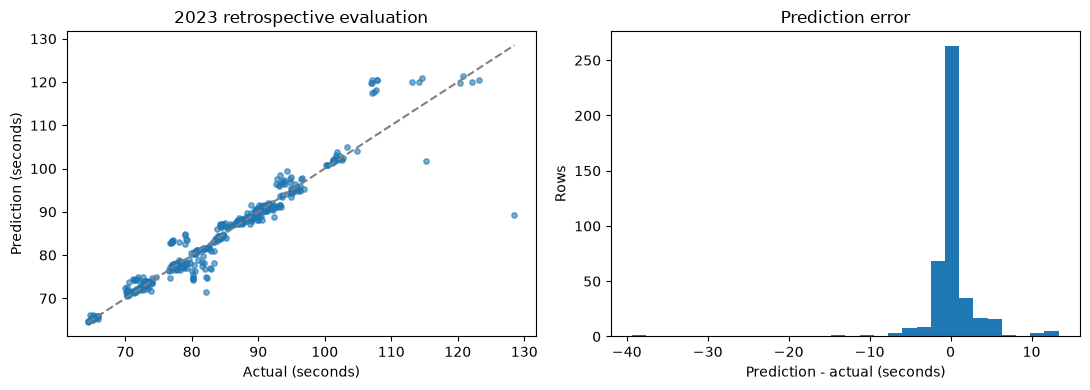

,event_id,Event,N,MAE,RMSE
0,2023-01,Bahrain Grand Prix,20,0.505764,0.607504
1,2023-02,Saudi Arabian Grand Prix,20,2.484297,8.815559
2,2023-03,Australian Grand Prix,19,0.413628,0.463624
3,2023-04,Azerbaijan Grand Prix,20,1.311307,3.136177
4,2023-05,Miami Grand Prix,20,0.525505,0.610691
5,2023-06,Monaco Grand Prix,20,0.476582,0.671561
6,2023-07,Spanish Grand Prix,20,0.525815,0.638597
7,2023-08,Canadian Grand Prix,20,2.449473,3.046552
8,2023-09,Austrian Grand Prix,20,0.352225,0.498907
9,2023-10,British Grand Prix,20,1.159667,1.494124


ตรวจแล้ว: raw CSV ไม่ถูกแก้ไข


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, test_prediction, s=15, alpha=.6)
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[0].plot(limits, limits, "--", color="gray")
axes[0].set(xlabel="Actual (seconds)", ylabel="Prediction (seconds)", title="2023 retrospective evaluation")
axes[1].hist(test_results.Error, bins=30)
axes[1].set(xlabel="Prediction - actual (seconds)", ylabel="Rows", title="Prediction error")
plt.tight_layout()
plt.show()

per_event = pd.DataFrame([
    {"event_id": event_id, "Event": group.EventName.iloc[0], "N": len(group),
     **scores(group.QualiTime, group.Prediction)}
    for event_id, group in test_results.groupby("event_id")
])
display(per_event)
per_event.to_csv(PROCESSED / "evaluation_by_event.csv", index=False)
assert csv_hashes(RAW) == raw_checksums, "raw เปลี่ยนระหว่างเตรียมข้อมูล/ฝึก"
print("ตรวจแล้ว: raw CSV ไม่ถูกแก้ไข")

### 5. Deployment

#### 5.1 บันทึกโมเดลเวลา + สนาม
บันทึก pipeline และ checksum ที่ `models/qualifying-circuit.joblib` เว็บโหลดไฟล์นี้เมื่อ restart

In [21]:
model_path = MODELS / "qualifying-circuit.joblib"
bundle = {
    "version": "practice-circuit-v1",
    "model": final_model,
    "features": FEATURES,
    "numeric_min": final_X.min(),
    "numeric_max": final_X.max(),
    "years": YEARS,
    "raw_checksums": raw_checksums,
    "circuit_checksum": hashlib.sha256(CIRCUIT_FILE.read_bytes()).hexdigest(),
}
joblib.dump(bundle, model_path)
print(model_path)


/workspace/f1_project/data/final/models/qualifying-circuit.joblib


#### 5.2 เลือกสนามและกรอกเวลาซ้อม
เลือก event_id เพื่อเติมความยาวและจำนวนโค้งของปีนั้น กรอกเวลาเป็นวินาที เว้น FP ที่ไม่มีเป็น None ไม่กรอกชนิดหรืออายุยาง

In [22]:
loaded = joblib.load(model_path)
# เลือกรายการเพื่อใช้ผังสนามของปีนั้น ไม่เอา event_id เข้าโมเดล
event_id = "2023-01"
circuit = circuits.set_index("event_id").loc[event_id]
new_data = pd.DataFrame([{
    "FP1_Time": 93.0, "FP2_Time": 91.0, "FP3_Time": None,
    "circuit_length_km": circuit.circuit_length_km,
    "corner_count": circuit.corner_count,
}])
filled_input = fill_sessions(new_data)
display(filled_input)
new_X = filled_input[loaded["features"]]
assert np.isfinite(new_X.to_numpy(dtype=float)).all() and new_X.gt(0).all().all()
outside = (new_X.lt(loaded["numeric_min"]) | new_X.gt(loaded["numeric_max"])).any()
print("Input นอกช่วงฝึก:", outside[outside].index.tolist())
prediction = float(loaded["model"].predict(new_X)[0])
assert np.isfinite(prediction) and prediction > 0, "ผลทำนายอยู่นอกขอบเขตที่ใช้ได้"
print(f"เวลา Qualifying ที่ทำนาย: {prediction:.3f} วินาที")
np.testing.assert_allclose(loaded["model"].predict(test[FEATURES]), test_prediction)


,FP1_Time,FP2_Time,FP3_Time,circuit_length_km,corner_count,FP1_filled_from,FP2_filled_from,FP3_filled_from
0,93.0,91.0,91.0,5.412,15,FP1,FP2,FP2


Input นอกช่วงฝึก: []
เวลา Qualifying ที่ทำนาย: 89.601 วินาที
